In [1]:
import pandas as pd

train = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["id", "title", "genre", "description"]
)

print(train.head())

   id                             title     genre  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   
3   4             The Secret Sin (1915)     drama   
4   5            The Unrecovered (2007)     drama   

                                         description  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  


In [2]:
import pandas as pd

train = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["id", "title", "genre", "description"]
)

print(train.head())

   id                             title     genre  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   
3   4             The Secret Sin (1915)     drama   
4   5            The Unrecovered (2007)     drama   

                                         description  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  


In [3]:
print("Dataset shape:")
print(train.shape)

print("\nGenre distribution:")
print(train["genre"].value_counts())

print("\nNumber of genres:")
print(train["genre"].nunique())

print("\nMissing values:")
print(train.isnull().sum())

print("\nRandom samples:")
print(train[["title", "genre", "description"]].sample(10))

Dataset shape:
(54214, 4)

Genre distribution:
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64

Number of genres:
27

Missing values:
id             0
title          0
genre          0
description    0
dtype: int64

Random samples:
                                     title        genre  \
10977         La mécanique des flux (2016)  documentary   
31569                     Lie Still (2005)       horror   
26852          Katastrofin aineksia (200

In [4]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [5]:
print("Duplicate descriptions:", train["description"].duplicated().sum())

Duplicate descriptions: 128


In [6]:
print("Duplicate IDs:", train["id"].duplicated().sum())

Duplicate IDs: 0


In [7]:
print("Empty descriptions:", (train["description"].str.strip() == "").sum())

Empty descriptions: 0


In [8]:
print("Shortest description length:",
      train["description"].str.len().min())

Shortest description length: 41


In [9]:
X = train["description"]
y = train["genre"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (54214,)
y shape: (54214,)


In [17]:
import re

X = train["description"].copy()
y = train["genre"].copy()

X = X.str.lower()

def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

X = X.apply(clean_text)

X = X.str.replace(r"\s+", " ", regex=True).str.strip()

print(X.head(5))

0    listening in to a conversation between his doc...
1    a brother and sister with a past incestuous re...
2    as the bus empties the students for their fiel...
3    to help their unemployed father make ends meet...
4    the films title refers not only to the unrecov...
Name: description, dtype: object


In [18]:
print("Original:")
print(train["description"].iloc[0])

print("\nCleaned:")
print(X.iloc[0])

Original:
Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.

Cleaned:
listening in to a conversation between his doctor and parents 10yearold oscar learns what nobody has the courage to tell him he only has a few weeks to live furious he refuses to speak to anyone except straighttalking rose the lady in pink he meets on the hospital stairs as christmas approaches rose uses her fantastical experiences as a professional wrestler her imagination wit and charm to allow oscar to live life and love to the

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))

print("\nTraining genre distribution:")
print(y_train.value_counts())

print("\nValidation genre distribution:")
print(y_valid.value_counts())

Training samples: 43371
Validation samples: 10843

Training genre distribution:
genre
drama          10890
documentary    10477
comedy          5957
short           4058
horror          1763
thriller        1273
action          1052
western          826
reality-tv       707
family           627
adventure        620
music            585
romance          538
sci-fi           518
adult            472
crime            404
animation        398
sport            346
talk-show        313
fantasy          258
mystery          255
musical          222
biography        212
history          194
game-show        155
news             145
war              106
Name: count, dtype: int64

Validation genre distribution:
genre
drama          2723
documentary    2619
comedy         1490
short          1015
horror          441
thriller        318
action          263
western         206
reality-tv      177
family          157
adventure       155
music           146
romance         134
sci-fi          129
adu

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)

Training TF-IDF shape: (43371, 50000)
Validation TF-IDF shape: (10843, 50000)


In [21]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_valid_tfidf)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_valid, y_pred_nb))

print("\nNaive Bayes Classification Report:")
print(classification_report(y_valid, y_pred_nb))

Naive Bayes Accuracy:
0.46785944849211475

Naive Bayes Classification Report:
              precision    recall  f1-score   support

      action       0.00      0.00      0.00       263
       adult       0.00      0.00      0.00       118
   adventure       0.00      0.00      0.00       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.63      0.18      0.29      1490
       crime       0.00      0.00      0.00       101
 documentary       0.53      0.92      0.67      2619
       drama       0.40      0.87      0.55      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       0.00      0.00      0.00        39
     history       0.00      0.00      0.00        49
      horror       1.00      0.02      0.04       441
       music       1.00      0.01      0.03       146
     musical       0.00      0.00      0.00        55
   

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_valid_tfidf)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_valid, y_pred_lr))

print("\nLogistic Regression Classification Report:")
print(classification_report(
    y_valid,
    y_pred_lr,
    zero_division=0
))

Logistic Regression Accuracy:
0.5791755049340589

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      action       0.60      0.22      0.32       263
       adult       0.75      0.28      0.41       118
   adventure       0.77      0.11      0.19       155
   animation       0.75      0.03      0.06       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.58      0.55      1490
       crime       0.33      0.01      0.02       101
 documentary       0.65      0.88      0.74      2619
       drama       0.53      0.80      0.64      2723
      family       0.71      0.08      0.14       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.31      0.47        39
     history       0.00      0.00      0.00        49
      horror       0.69      0.54      0.61       441
       music       0.68      0.34      0.46       146
     musical       0.00      0.00      0.0

In [26]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_valid_tfidf)

print("SVM Accuracy:")
print(accuracy_score(y_valid, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(
    y_valid,
    y_pred_svm,
    zero_division=0
))

SVM Accuracy:
0.5792677303329337

SVM Classification Report:
              precision    recall  f1-score   support

      action       0.47      0.36      0.41       263
       adult       0.68      0.45      0.54       118
   adventure       0.47      0.22      0.30       155
   animation       0.43      0.16      0.23       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.59      0.55      1490
       crime       0.23      0.05      0.08       101
 documentary       0.68      0.83      0.75      2619
       drama       0.56      0.70      0.62      2723
      family       0.45      0.16      0.24       157
     fantasy       0.15      0.03      0.05        65
   game-show       0.92      0.59      0.72        39
     history       0.40      0.04      0.07        49
      horror       0.62      0.63      0.62       441
       music       0.61      0.51      0.56       146
     musical       0.33      0.04      0.07        55
     mystery       0

In [27]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_balanced = LinearSVC(class_weight="balanced")

svm_balanced.fit(X_train_tfidf, y_train)

y_pred_svm_balanced = svm_balanced.predict(X_valid_tfidf)

print("Balanced SVM Accuracy:")
print(accuracy_score(y_valid, y_pred_svm_balanced))

print("\nBalanced SVM Classification Report:")
print(classification_report(
    y_valid,
    y_pred_svm_balanced,
    zero_division=0
))

Balanced SVM Accuracy:
0.5542746472378492

Balanced SVM Classification Report:
              precision    recall  f1-score   support

      action       0.34      0.49      0.40       263
       adult       0.45      0.67      0.54       118
   adventure       0.26      0.30      0.28       155
   animation       0.20      0.25      0.23       100
   biography       0.00      0.00      0.00        53
      comedy       0.58      0.56      0.57      1490
       crime       0.19      0.19      0.19       101
 documentary       0.74      0.76      0.75      2619
       drama       0.65      0.54      0.59      2723
      family       0.22      0.25      0.23       157
     fantasy       0.13      0.11      0.12        65
   game-show       0.60      0.62      0.61        39
     history       0.16      0.12      0.14        49
      horror       0.55      0.70      0.61       441
       music       0.49      0.71      0.58       146
     musical       0.16      0.15      0.15        55
  

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

tfidf_uni = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 1)
)

X_train_uni = tfidf_uni.fit_transform(X_train)
X_valid_uni = tfidf_uni.transform(X_valid)

svm_uni = LinearSVC()

svm_uni.fit(X_train_uni, y_train)

y_pred_uni = svm_uni.predict(X_valid_uni)

accuracy_uni = accuracy_score(y_valid, y_pred_uni)

print("Unigram TF-IDF + SVM Accuracy:")
print(accuracy_uni)

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_pred_uni,
    zero_division=0
))

Unigram TF-IDF + SVM Accuracy:
0.5734575302038182

Classification Report:
              precision    recall  f1-score   support

      action       0.46      0.37      0.41       263
       adult       0.65      0.49      0.56       118
   adventure       0.44      0.22      0.29       155
   animation       0.30      0.14      0.19       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.58      0.55      1490
       crime       0.19      0.05      0.08       101
 documentary       0.68      0.82      0.74      2619
       drama       0.56      0.70      0.62      2723
      family       0.43      0.15      0.22       157
     fantasy       0.20      0.03      0.05        65
   game-show       0.88      0.54      0.67        39
     history       0.40      0.04      0.07        49
      horror       0.62      0.60      0.61       441
       music       0.64      0.48      0.55       146
     musical       0.14      0.02      0.03        55
     my

In [1]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# 1. LOAD TRAINING DATA
# --------------------------------------------------

train = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["id", "title", "genre", "description"]
)

print("Training data shape:", train.shape)


# --------------------------------------------------
# 2. BASIC DATA CHECK
# --------------------------------------------------

print("\nMissing values:")
print(train.isnull().sum())

print("\nNumber of genres:")
print(train["genre"].nunique())

print("\nGenre distribution:")
print(train["genre"].value_counts())


# --------------------------------------------------
# 3. PREPARE X AND Y
# --------------------------------------------------

X = train["description"].copy()
y = train["genre"].copy()


# --------------------------------------------------
# 4. TEXT PREPROCESSING
# --------------------------------------------------

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


X = X.apply(clean_text)


# --------------------------------------------------
# 5. TRAIN / VALIDATION SPLIT
# --------------------------------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_valid))


# --------------------------------------------------
# 6. TF-IDF
# --------------------------------------------------

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

print("\nTraining TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)


# --------------------------------------------------
# 7. NAIVE BAYES
# --------------------------------------------------

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_valid_tfidf)

nb_accuracy = accuracy_score(y_valid, y_pred_nb)

print("\n==============================")
print("NAIVE BAYES")
print("==============================")

print("Accuracy:", nb_accuracy)

print(
    classification_report(
        y_valid,
        y_pred_nb,
        zero_division=0
    )
)


# --------------------------------------------------
# 8. LOGISTIC REGRESSION
# --------------------------------------------------

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_valid_tfidf)

lr_accuracy = accuracy_score(y_valid, y_pred_lr)

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print("Accuracy:", lr_accuracy)

print(
    classification_report(
        y_valid,
        y_pred_lr,
        zero_division=0
    )
)


# --------------------------------------------------
# 9. NORMAL SVM
# --------------------------------------------------

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_valid_tfidf)

svm_accuracy = accuracy_score(y_valid, y_pred_svm)

print("\n==============================")
print("NORMAL SVM")
print("==============================")

print("Accuracy:", svm_accuracy)

print(
    classification_report(
        y_valid,
        y_pred_svm,
        zero_division=0
    )
)


# --------------------------------------------------
# 10. BALANCED SVM
# --------------------------------------------------

svm_balanced = LinearSVC(
    class_weight="balanced"
)

svm_balanced.fit(X_train_tfidf, y_train)

y_pred_svm_balanced = svm_balanced.predict(X_valid_tfidf)

balanced_svm_accuracy = accuracy_score(
    y_valid,
    y_pred_svm_balanced
)

print("\n==============================")
print("BALANCED SVM")
print("==============================")

print("Accuracy:", balanced_svm_accuracy)

print(
    classification_report(
        y_valid,
        y_pred_svm_balanced,
        zero_division=0
    )
)


# --------------------------------------------------
# 11. MODEL COMPARISON
# --------------------------------------------------

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(
    "Naive Bayes Accuracy:",
    nb_accuracy
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

print(
    "Normal SVM Accuracy:",
    svm_accuracy
)

print(
    "Balanced SVM Accuracy:",
    balanced_svm_accuracy
)


# --------------------------------------------------
# 12. FINAL MODEL
# --------------------------------------------------
# We select Normal SVM based on the highest
# validation accuracy among our tested models.
#
# We now retrain TF-IDF and SVM using ALL
# available labeled training data.
# --------------------------------------------------

final_tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

X_full_tfidf = final_tfidf.fit_transform(X)

final_svm = LinearSVC()

final_svm.fit(X_full_tfidf, y)

print("\nFinal model trained successfully.")


# --------------------------------------------------
# 13. LOAD TEST DATA
# --------------------------------------------------

test = pd.read_csv(
    "test_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["id", "title", "description"]
)

print("\nTest data shape:", test.shape)


# --------------------------------------------------
# 14. PREPROCESS TEST DATA
# --------------------------------------------------

X_test = test["description"].copy()

X_test = X_test.apply(clean_text)


# --------------------------------------------------
# 15. TRANSFORM TEST DATA USING THE SAME TF-IDF
# --------------------------------------------------

X_test_tfidf = final_tfidf.transform(X_test)


# --------------------------------------------------
# 16. PREDICT TEST GENRES
# --------------------------------------------------

test_predictions = final_svm.predict(
    X_test_tfidf
)


# --------------------------------------------------
# 17. CREATE RESULTS DATAFRAME
# --------------------------------------------------

results = pd.DataFrame({
    "id": test["id"],
    "title": test["title"],
    "predicted_genre": test_predictions
})

print("\nPredictions:")
print(results.head(10))


# --------------------------------------------------
# 18. LOAD TEST SOLUTION
# --------------------------------------------------

test_solution = pd.read_csv(
    "test_data_solution.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["id", "title", "genre", "description"]
)

print("\nTest solution shape:", test_solution.shape)


# --------------------------------------------------
# 19. FINAL TEST EVALUATION
# --------------------------------------------------

final_accuracy = accuracy_score(
    test_solution["genre"],
    test_predictions
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("Final Test Accuracy:", final_accuracy)

print("\nFinal Classification Report:")

print(
    classification_report(
        test_solution["genre"],
        test_predictions,
        zero_division=0
    )
)


# --------------------------------------------------
# 20. CONFUSION MATRIX
# --------------------------------------------------

cm = confusion_matrix(
    test_solution["genre"],
    test_predictions
)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------------------------
# 21. SAVE PREDICTIONS
# --------------------------------------------------

results.to_csv(
    "movie_genre_predictions.csv",
    index=False
)

print(
    "\nPredictions saved as movie_genre_predictions.csv"
)

Training data shape: (54214, 4)

Missing values:
id             0
title          0
genre          0
description    0
dtype: int64

Number of genres:
27

Genre distribution:
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64

Training samples: 43371
Validation samples: 10843

Training TF-IDF shape: (43371, 50000)
Validation TF-IDF shape: (10843, 50000)

NAIVE BAYES
Accuracy: 0.46785944849211475
              precision    recall  f1-score   support



In [2]:
print(results.head(10))
print(results.shape)

   id                                       title predicted_genre
0   1                        Edgar's Lunch (1998)          comedy
1   2                    La guerra de papá (1977)           drama
2   3                 Off the Beaten Track (2010)     documentary
3   4                      Meu Amigo Hindu (2015)           drama
4   5                           Er nu zhai (1955)           drama
5   6                          Riddle Room (2016)           drama
6   7                              L'amica (1969)           drama
7   8                        Ina Mina Dika (1989)          comedy
8   9  Equinox Special: Britain's Tornados (2005)     documentary
9  10                                Press (2011)     documentary
(54200, 3)


In [3]:
print("Final Test Accuracy:", final_accuracy)

print("\nFinal Classification Report:")
print(
    classification_report(
        test_solution["genre"],
        test_predictions,
        zero_division=0
    )
)

Final Test Accuracy: 0.5863284132841329

Final Classification Report:
              precision    recall  f1-score   support

      action       0.43      0.33      0.37      1314
       adult       0.62      0.40      0.49       590
   adventure       0.49      0.21      0.30       775
   animation       0.38      0.13      0.19       498
   biography       0.00      0.00      0.00       264
      comedy       0.54      0.59      0.56      7446
       crime       0.23      0.06      0.10       505
 documentary       0.69      0.83      0.76     13096
       drama       0.57      0.72      0.63     13612
      family       0.39      0.15      0.21       783
     fantasy       0.35      0.08      0.13       322
   game-show       0.81      0.65      0.72       193
     history       0.20      0.02      0.03       243
      horror       0.61      0.64      0.63      2204
       music       0.63      0.53      0.57       731
     musical       0.33      0.07      0.12       276
     myster

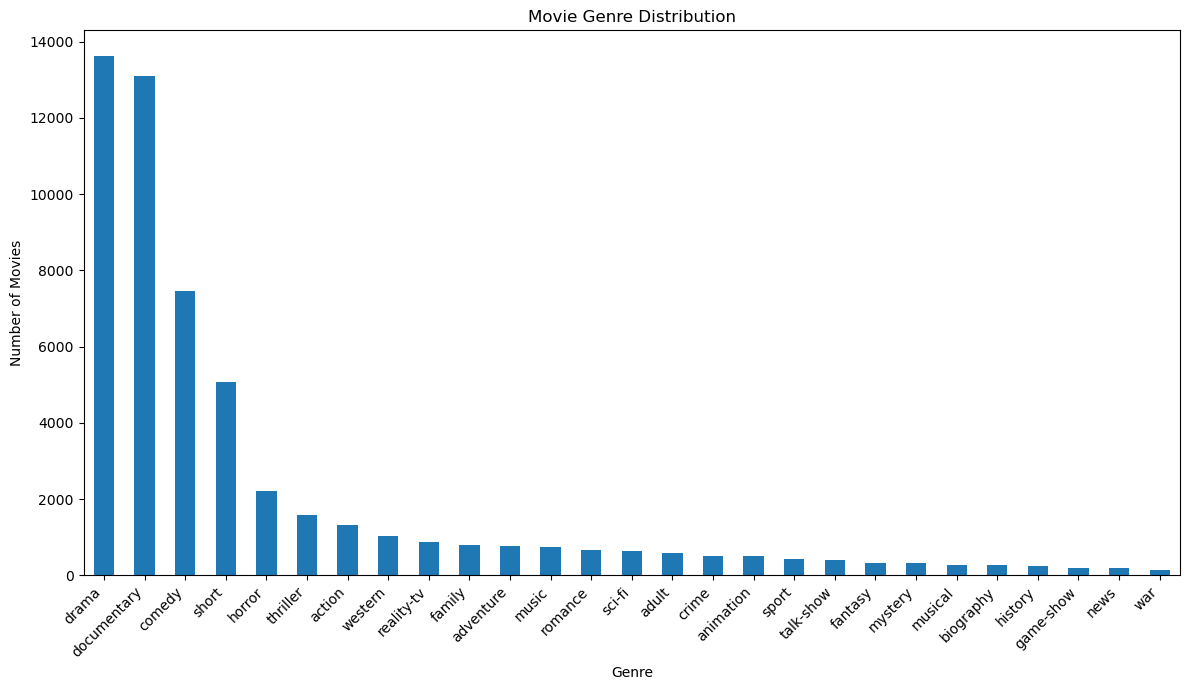

In [4]:
import matplotlib.pyplot as plt

genre_counts = train["genre"].value_counts()

plt.figure(figsize=(12, 7))
genre_counts.plot(kind="bar")

plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("genre_distribution.png", dpi=300)
plt.show()

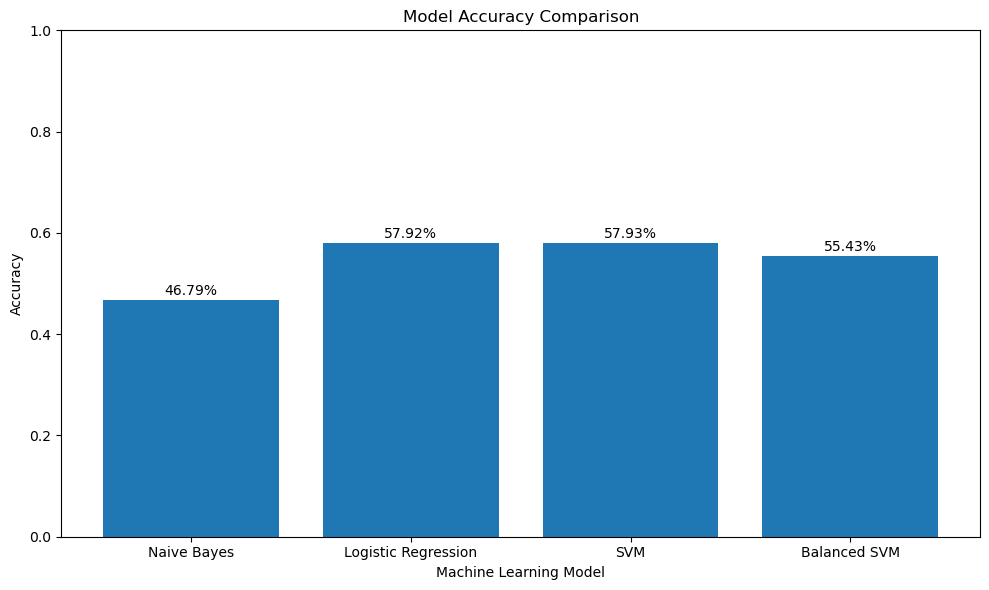

In [5]:
import matplotlib.pyplot as plt

models = [
    "Naive Bayes",
    "Logistic Regression",
    "SVM",
    "Balanced SVM"
]

accuracies = [
    nb_accuracy,
    lr_accuracy,
    svm_accuracy,
    balanced_svm_accuracy
]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.01,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300)
plt.show()

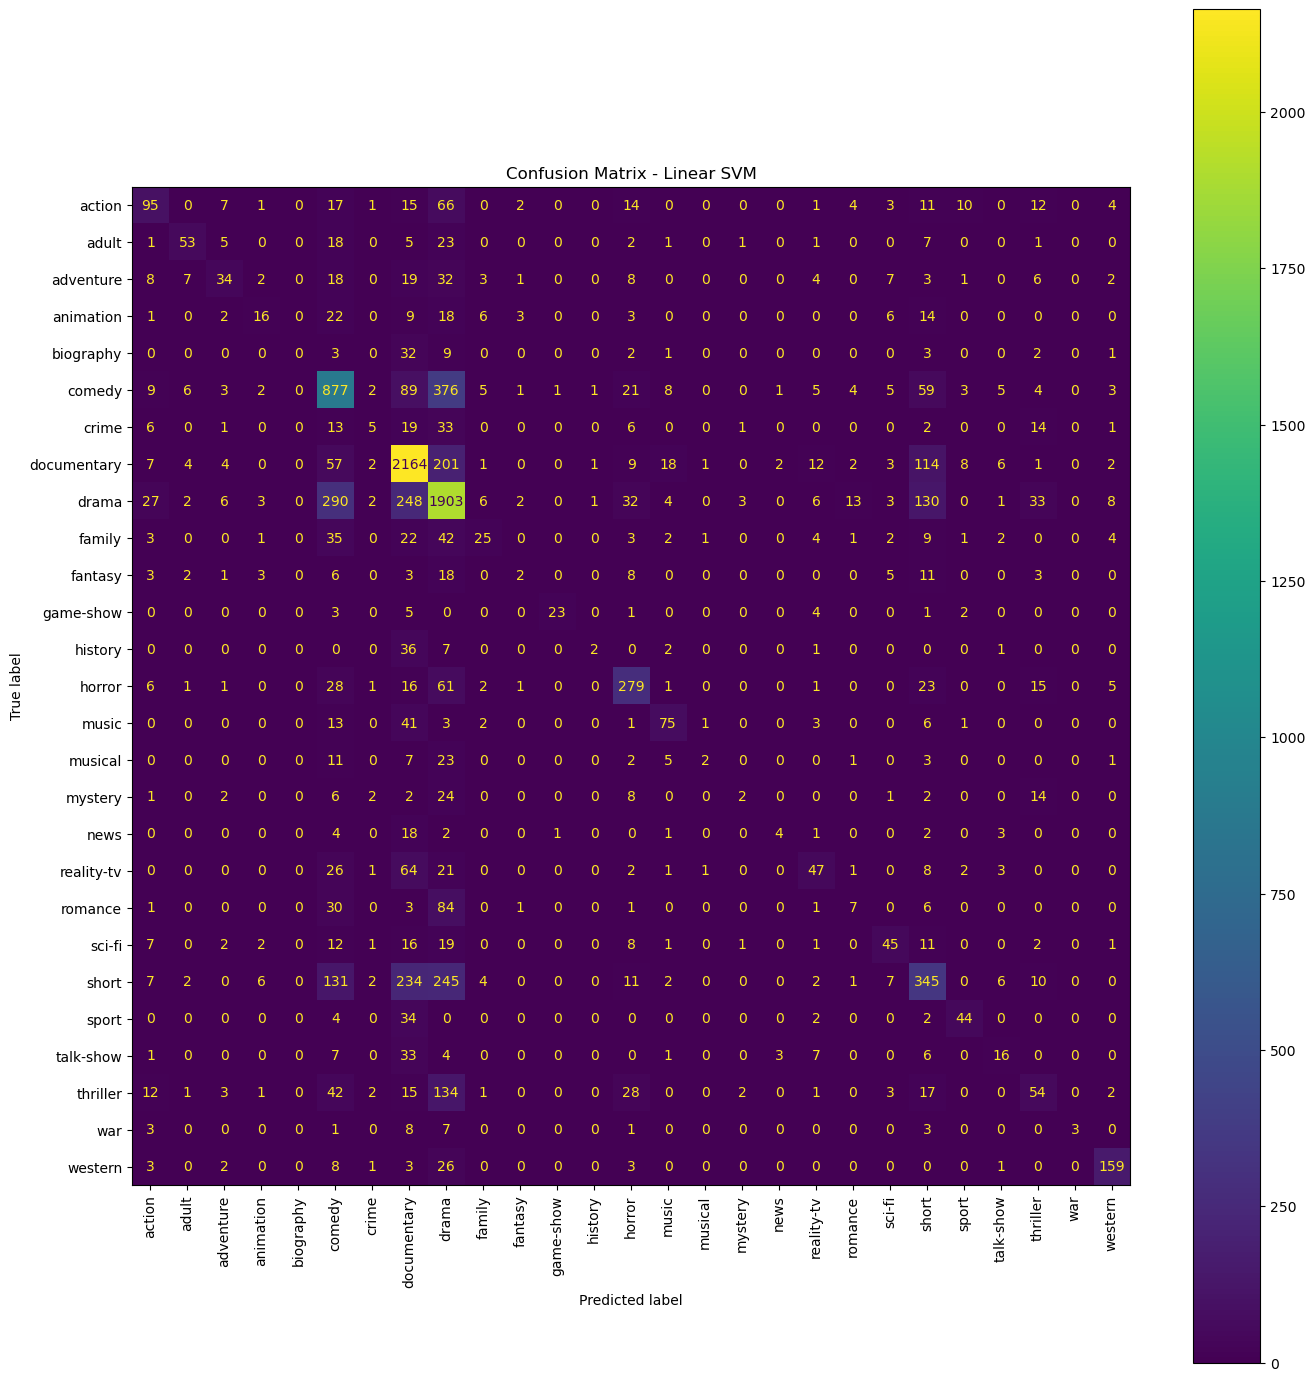

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred_svm,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("Confusion Matrix - Linear SVM")

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [8]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "Balanced SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy,
        balanced_svm_accuracy
    ]
})

model_results["Accuracy (%)"] = (
    model_results["Accuracy"] * 100
).round(2)

print(model_results)

                 Model  Accuracy  Accuracy (%)
0          Naive Bayes  0.467859         46.79
1  Logistic Regression  0.579176         57.92
2                  SVM  0.579268         57.93
3         Balanced SVM  0.554275         55.43


In [10]:
model_results.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [12]:
import joblib

joblib.dump(final_tfidf, "tfidf_vectorizer.pkl")
joblib.dump(final_svm, "movie_genre_model.pkl")

print("TF-IDF vectorizer saved.")
print("Movie genre model saved.")

TF-IDF vectorizer saved.
Movie genre model saved.
